# PolyPharmGuard: Complete Research Pipeline
### An Explainable AI System for Polypharmacy Risk Detection
**Author:** Alfred Bartholomew Sunday  
**Student ID:** 2429712  
**Supervisor:** Dr Anthony Ojo


# DATA COLLECTION & PREPROCESSING

## Install & Import All Libraries

In [1]:
!pip install requests pandas numpy scikit-learn tqdm matplotlib seaborn xgboost lightgbm imbalanced-learn joblib shap dill -q

import requests
import pandas as pd
import numpy as np
import time
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap

shap.initjs()

SEED = 42
np.random.seed(SEED)

print(' All libraries loaded successfully')
print(f'   XGBoost: {xgb.__version__} | SHAP: {shap.__version__}')

 All libraries loaded successfully
   XGBoost: 3.3.0 | SHAP: 0.52.0


## [3.2] Anticholinergic Cognitive Burden (ACB) Scale & Drug Knowledge Base

In [2]:
# ACB Score Dictionary with drug names in lowercase and ACB score ranked 0-3
# Source: Bishara et al. (2017)

ACB_SCORES = {
    'amitriptyline': 3, 'amoxapine': 3, 'atropine': 3, 'benztropine': 3,
    'brompheniramine': 3, 'carbinoxamine': 3, 'chlorpheniramine': 3,
    'chlorpromazine': 3, 'clomipramine': 3, 'clozapine': 3,
    'cyclobenzaprine': 3, 'cyproheptadine': 3, 'desipramine': 3,
    'dicyclomine': 3, 'dimenhydrinate': 3, 'diphenhydramine': 3,
    'doxepin': 3, 'doxylamine': 3, 'flavoxate': 3, 'hydroxyzine': 3,
    'hyoscyamine': 3, 'imipramine': 3, 'meclizine': 3, 'nortriptyline': 3,
    'olanzapine': 3, 'orphenadrine': 3, 'oxybutynin': 3, 'paroxetine': 3,
    'perphenazine': 3, 'promethazine': 3, 'propantheline': 3,
    'scopolamine': 3, 'thioridazine': 3, 'tolterodine': 3,
    'trifluoperazine': 3, 'trimipramine': 3, 'trospium': 3,
    # Score 2 — Possible anticholinergic
    'amantadine': 2, 'belladonna': 2, 'carbamazepine': 2,
    'loxapine': 2, 'meperidine': 2, 'molindone': 2,
    'oxcarbazepine': 2, 'pimozide': 2, 'quetiapine': 2,
    'risperidone': 2, 'tizanidine': 2,
    # Score 1 — Mild anticholinergic
    'bupropion': 1, 'captopril': 1, 'codeine': 1, 'colchicine': 1,
    'diazepam': 1, 'digoxin': 1, 'furosemide': 1, 'haloperidol': 1,
    'hydralazine': 1, 'isosorbide': 1, 'metoprolol': 1, 'morphine': 1,
    'nifedipine': 1, 'prednisolone': 1, 'prednisone': 1,
    'ranitidine': 1, 'theophylline': 1, 'tramadol': 1,
    'triamterene': 1, 'warfarin': 1,
}

HIGH_RISK_COMBOS = [
    {'warfarin', 'aspirin'}, {'warfarin', 'ibuprofen'},
    {'digoxin', 'amiodarone'}, {'lithium', 'ibuprofen'},
    {'clopidogrel', 'omeprazole'}, {'simvastatin', 'amiodarone'},
    {'tacrolimus', 'fluconazole'}, {'warfarin', 'fluconazole'},
    {'atorvastatin', 'clarithromycin'},
]

CNS_DRUGS = {
    'antidepressants': ['amitriptyline','fluoxetine','sertraline','paroxetine','venlafaxine',
                        'duloxetine','citalopram','escitalopram','bupropion','mirtazapine',
                        'nortriptyline','desipramine','imipramine','clomipramine','trazodone'],
    'antipsychotics':  ['haloperidol','risperidone','olanzapine','quetiapine','aripiprazole',
                        'clozapine','ziprasidone','chlorpromazine','thioridazine'],
    'benzodiazepines': ['diazepam','lorazepam','alprazolam','clonazepam','temazepam',
                        'midazolam','oxazepam','triazolam','nitrazepam','flurazepam'],
    'opioids':         ['morphine','oxycodone','hydrocodone','codeine','tramadol','fentanyl',
                        'buprenorphine','methadone','hydromorphone','meperidine'],
    'anticonvulsants': ['carbamazepine','valproate','lamotrigine','levetiracetam',
                        'phenytoin','gabapentin','pregabalin','topiramate','oxcarbazepine'],
}
ALL_CNS = [drug for cat in CNS_DRUGS.values() for drug in cat]

FEATURE_COLUMNS = [
    'age', 'sex_encoded', 'weight_kg', 'num_drugs',
    'acb_total', 'acb_max', 'acb_drug_count',
    'polypharmacy_flag', 'high_risk_combo',
    'cns_drug_count', 'age_risk'
]

FEATURE_LABELS = {
    'age':              'Patient Age',
    'sex_encoded':      'Sex (0=M, 1=F)',
    'weight_kg':        'Weight (kg)',
    'num_drugs':        'Number of Drugs',
    'acb_total':        'ACB Total Score',
    'acb_max':          'ACB Max Score',
    'acb_drug_count':   'Anticholinergic Drug Count',
    'polypharmacy_flag':'Polypharmacy (5+ drugs)',
    'high_risk_combo':  'High-Risk Drug Combo',
    'cns_drug_count':   'CNS Drug Count',
    'age_risk':         'Elderly Risk (65+)',
}

print(f' Knowledge base loaded: {len(ACB_SCORES)} ACB-scored drugs, {len(HIGH_RISK_COMBOS)} risk combos')

 Knowledge base loaded: 68 ACB-scored drugs, 9 risk combos


## [3.3] Pull Data from FDA OpenFDA API

In [3]:
BASE_URL = 'https://api.fda.gov/drug/event.json'

def fetch_fda_events(total_records=5000, batch_size=100):
    all_records = []
    skip = 0
    print(f'Fetching {total_records} records from FDA OpenFDA API...')
    with tqdm(total=total_records, unit='records') as pbar:
        while len(all_records) < total_records:
            params = {
                'limit': min(batch_size, total_records - len(all_records)),
                'skip':  skip
            }
            try:
                resp = requests.get(BASE_URL, params=params, timeout=15)
                if resp.status_code != 200:
                    time.sleep(2); continue
                results = resp.json().get('results', [])
                if not results: break
                all_records.extend(results)
                pbar.update(len(results))
                skip += batch_size
                time.sleep(0.4)
            except Exception as e:
                print(f'\n Error: {e}'); time.sleep(3)
    print(f'\n Fetched {len(all_records)} raw records')
    return all_records

raw_records = fetch_fda_events(total_records=5000)

Fetching 5000 records from FDA OpenFDA API...


100%|██████████| 5000/5000 [02:45<00:00, 30.27records/s]


 Fetched 5000 raw records


## Parse, Feature Engineering  And Label

In [5]:
def parse_record(record):
    patient = record.get('patient', {})
    try:    age = float(patient.get('patientonsetage', np.nan))
    except: age = np.nan
    sex = {'1':'male','2':'female'}.get(str(patient.get('patientsex','')),'unknown')
    try:    weight = float(patient.get('patientweight', np.nan))
    except: weight = np.nan
    drugs_raw  = patient.get('drug', [])
    drug_names = []
    for d in drugs_raw:
        name = d.get('medicinalproduct','') or d.get('activesubstance',{}).get('activesubstancename','')
        if name: drug_names.append(name.lower().strip())
    reactions = [r.get('reactionmeddrapt','').lower() for r in patient.get('reaction',[]) if r.get('reactionmeddrapt')]
    return {
        'age': age, 'sex': sex, 'weight_kg': weight,
        'num_drugs': len(drug_names),
        'drug_names': '|'.join(drug_names),
        'reactions':  '|'.join(reactions),
        'serious':           int(record.get('serious', 0) or 0),
        'hospitalised':      int(record.get('seriousnesshospitalization', 0) or 0),
        'death':             int(record.get('seriousnessdeath', 0) or 0),
        'life_threatening':  int(record.get('seriousnesslifethreatening', 0) or 0),
    }

def compute_acb(drug_str):
    if not drug_str or pd.isna(drug_str): return 0, 0, 0
    drugs  = [d.strip() for d in drug_str.split('|') if d.strip()]
    scores = [ACB_SCORES.get(d, 0) for d in drugs]
    return sum(scores), max(scores) if scores else 0, sum(1 for s in scores if s > 0)

def check_combo(drug_str):
    if not drug_str or pd.isna(drug_str): return 0
    drugs = set(d.strip() for d in drug_str.split('|') if d.strip())
    for combo in HIGH_RISK_COMBOS:
        if combo.issubset(drugs): return 1
    if 'warfarin' in drugs and drugs & {'aspirin','ibuprofen','naproxen'}: return 1
    opioids = {'morphine','oxycodone','hydrocodone','fentanyl','codeine','tramadol'}
    benzos  = {'diazepam','lorazepam','alprazolam','clonazepam'}
    if drugs & opioids and drugs & benzos: return 1
    return 0

def count_cns(drug_str):
    if not drug_str or pd.isna(drug_str): return 0
    return sum(1 for d in drug_str.split('|') if d.strip() in ALL_CNS)

def create_label(row):
    score = 0
    if row['serious'] == 1:          score += 2
    if row['hospitalised'] == 1:     score += 2
    if row['death'] == 1:            score += 3
    if row['life_threatening'] == 1: score += 2
    if row['acb_total'] >= 3:        score += 2
    if row['acb_max'] == 3:          score += 1
    if row['polypharmacy_flag'] == 1: score += 1
    if row['high_risk_combo'] == 1:  score += 2
    if row['cns_drug_count'] >= 2:   score += 1
    if row['age_risk'] == 1:         score += 1
    return 1 if score >= 4 else 0

print(' Parsing & engineering features...')
df = pd.DataFrame([parse_record(r) for r in raw_records])

acb = df['drug_names'].apply(compute_acb)
df['acb_total']        = [x[0] for x in acb]
df['acb_max']          = [x[1] for x in acb]
df['acb_drug_count']   = [x[2] for x in acb]
df['polypharmacy_flag']= (df['num_drugs'] >= 5).astype(int)
df['high_risk_combo']  = df['drug_names'].apply(check_combo)
df['cns_drug_count']   = df['drug_names'].apply(count_cns)
df['age_risk']         = (df['age'] >= 65).astype(int)
df['sex_encoded']      = df['sex'].map({'male':0,'female':1,'unknown':-1})
df['age_group']        = pd.cut(df['age'], bins=[0,17,44,64,74,200],
                                 labels=['child','young_adult','middle_age','older_adult','elderly'])
df['risk_label']       = df.apply(create_label, axis=1)

# Clean
df = df[(df['num_drugs'] >= 1)]
df = df[(df['age'].isna()) | ((df['age'] >= 18) & (df['age'] <= 110))]
df['age']       = df['age'].fillna(df['age'].median())
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())
df['sex_encoded'] = df['sex_encoded'].replace(-1, df['sex_encoded'].mode()[0])
df = df.dropna(subset=FEATURE_COLUMNS)

print(f' Dataset ready: {df.shape[0]} records')
vc = df['risk_label'].value_counts()
print(f'   Low risk (0): {vc.get(0,0)}  |  High risk (1): {vc.get(1,0)}')

 Parsing & engineering features...
 Dataset ready: 4792 records
   Low risk (0): 3393  |  High risk (1): 1399


## Exploratory Data Analysis

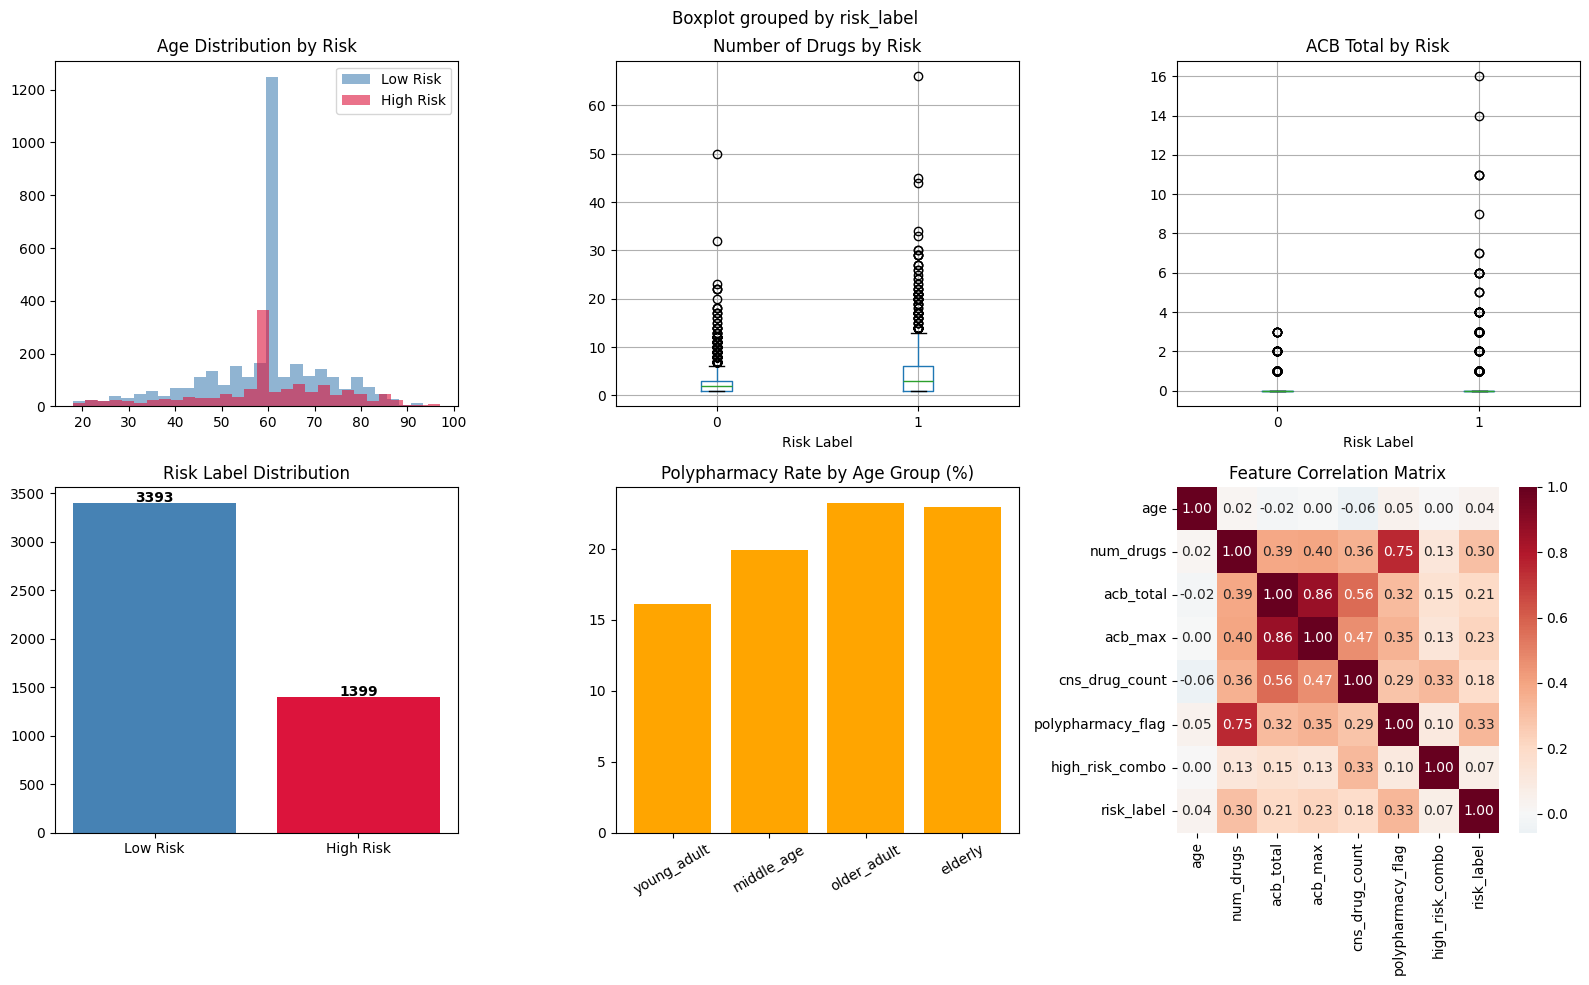

EDA plots saved


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PolyGuard — Exploratory Data Analysis', fontsize=16, fontweight='bold')

axes[0,0].hist(df[df['risk_label']==0]['age'], alpha=0.6, bins=30, label='Low Risk',  color='steelblue')
axes[0,0].hist(df[df['risk_label']==1]['age'], alpha=0.6, bins=30, label='High Risk', color='crimson')
axes[0,0].set_title('Age Distribution by Risk'); axes[0,0].legend()

df.boxplot(column='num_drugs',  by='risk_label', ax=axes[0,1])
axes[0,1].set_title('Number of Drugs by Risk'); axes[0,1].set_xlabel('Risk Label')

df.boxplot(column='acb_total', by='risk_label', ax=axes[0,2])
axes[0,2].set_title('ACB Total by Risk'); axes[0,2].set_xlabel('Risk Label')

rc = df['risk_label'].value_counts()
axes[1,0].bar(['Low Risk','High Risk'], rc.values, color=['steelblue','crimson'])
axes[1,0].set_title('Risk Label Distribution')
for i,v in enumerate(rc.values): axes[1,0].text(i, v+10, str(v), ha='center', fontweight='bold')

poly = df.groupby('age_group')['polypharmacy_flag'].mean()*100
axes[1,1].bar(poly.index.astype(str), poly.values, color='orange')
axes[1,1].set_title('Polypharmacy Rate by Age Group (%)')
axes[1,1].tick_params(axis='x', rotation=30)

corr_cols = ['age','num_drugs','acb_total','acb_max','cns_drug_count','polypharmacy_flag','high_risk_combo','risk_label']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2], cmap='RdBu_r', center=0)
axes[1,2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved')

## Save Dataset

In [8]:
df.to_csv('polyguard_dataset.csv', index=False)
df[FEATURE_COLUMNS + ['risk_label']].to_csv('polyguard_features.csv', index=False)

print(' Dataset saved')
print(f'   Records: {len(df)}  |  Features: {len(FEATURE_COLUMNS)}  |  High risk: {df["risk_label"].sum()} ({df["risk_label"].mean()*100:.1f}%)')
print('   Saved: polyguard_dataset.csv, polyguard_features.csv')

 Dataset saved
   Records: 4792  |  Features: 11  |  High risk: 1399 (29.2%)
   Saved: polyguard_dataset.csv, polyguard_features.csv


# MODEL TRAINING & EVALUATION

## Train/Test Split And SMOTE

In [9]:
X = df[FEATURE_COLUMNS]
y = df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print(f'Split & SMOTE complete')
print(f'Train (balanced): {X_train_bal.shape[0]}  |  Test: {X_test.shape[0]}')

Split & SMOTE complete
Train (balanced): 5428  |  Test: 959


## Baseline Model Comparison

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1),
}

results = []
print(' Comparing models...\n')
for name, model in models.items():
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train_bal
    Xte = X_test_scaled  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train_bal)
    yp   = model.predict(Xte)
    ypr  = model.predict_proba(Xte)[:,1]
    results.append({'Model': name,
                    'Accuracy':      accuracy_score(y_test, yp),
                    'F1 Score':      f1_score(y_test, yp),
                    'ROC-AUC':       roc_auc_score(y_test, ypr),
                    'Avg Precision': average_precision_score(y_test, ypr)})
    print(f'  {name:<25} Acc={results[-1]["Accuracy"]:.3f}  F1={results[-1]["F1 Score"]:.3f}  AUC={results[-1]["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(f'\n Best: {results_df.iloc[0]["Model"]}')
results_df

 Comparing models...

  Logistic Regression       Acc=0.668  F1=0.518  AUC=0.695
  Random Forest             Acc=0.674  F1=0.483  AUC=0.660
  XGBoost                   Acc=0.685  F1=0.478  AUC=0.662
  LightGBM                  Acc=0.689  F1=0.479  AUC=0.669

 Best: Logistic Regression


,Model,Accuracy,F1 Score,ROC-AUC,Avg Precision
0,Logistic Regression,0.668405,0.518182,0.694861,0.540535
3,LightGBM,0.689260,0.479021,0.668980,0.539900
2,XGBoost,0.685089,0.477509,0.662316,0.523166
1,Random Forest,0.673618,0.482645,0.659902,0.473113


## XGBoost Hyperparameter Tuning

In [11]:
print(' Tuning XGBoost (2-3 minutes)...')

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', verbosity=0, random_state=SEED),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_bal, y_train_bal)

best_model = grid.best_estimator_
print(f'\n Best params: {grid.best_params_}')
print(f'   CV ROC-AUC:  {grid.best_score_:.4f}')

 Tuning XGBoost (2-3 minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
   CV ROC-AUC:  0.7960


## Final Evaluation And Plots

In [12]:
y_pred   = best_model.predict(X_test)
y_proba  = best_model.predict_proba(X_test)[:,1]
cm       = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('FINAL MODEL PERFORMANCE')
print('='*45)
print(f'Accuracy:          {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score:          {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_proba):.4f}')
print(f'Avg Precision:     {average_precision_score(y_test, y_proba):.4f}')
print(f'Sensitivity:       {tp/(tp+fn):.4f}')
print(f'Specificity:       {tn/(tn+fp):.4f}')
print('='*45)
print(classification_report(y_test, y_pred, target_names=['Low Risk','High Risk']))

# Cross-validation
cv_scores = cross_val_score(best_model, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

FINAL MODEL PERFORMANCE
Accuracy:          0.6809
F1 Score:          0.4796
ROC-AUC:           0.6535
Avg Precision:     0.5161
Sensitivity:       0.5036
Specificity:       0.7541
              precision    recall  f1-score   support

    Low Risk       0.79      0.75      0.77       679
   High Risk       0.46      0.50      0.48       280

    accuracy                           0.68       959
   macro avg       0.62      0.63      0.62       959
weighted avg       0.69      0.68      0.69       959

5-Fold CV ROC-AUC: 0.7960 ± 0.0138


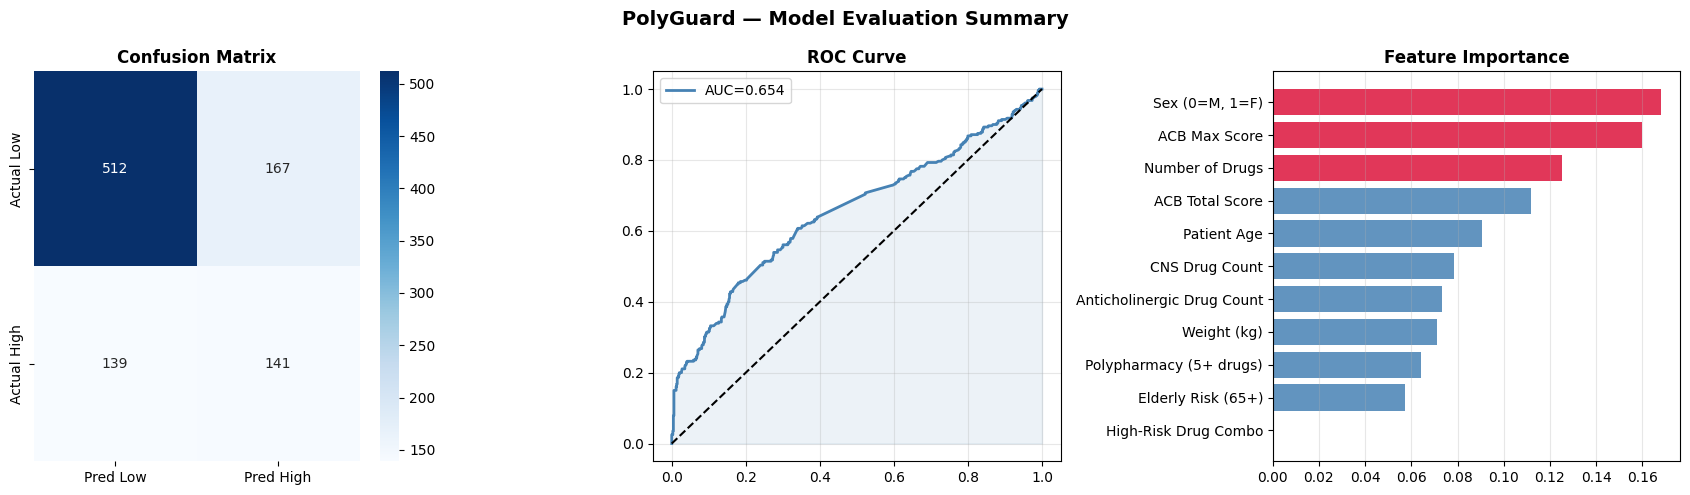

Saved model_evaluation.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Low','Pred High'], yticklabels=['Actual Low','Actual High'])
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc_auc_score(y_test,y_proba):.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Feature importance
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
top3 = feat_imp.nlargest(3).index
colors = ['crimson' if f in top3 else 'steelblue' for f in feat_imp.index]
axes[2].barh([FEATURE_LABELS.get(f,f) for f in feat_imp.index], feat_imp.values, color=colors, alpha=0.85)
axes[2].set_title('Feature Importance', fontweight='bold'); axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('PolyGuard — Model Evaluation Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_evaluation.png')

## Save Model Artefacts

In [14]:
joblib.dump(best_model, 'polyguard_model.pkl')
joblib.dump(scaler,     'polyguard_scaler.pkl')
with open('polyguard_features_list.json','w') as f:
    json.dump(FEATURE_COLUMNS, f)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
pd.DataFrame(X_train_bal, columns=FEATURE_COLUMNS).to_csv('X_train_balanced.csv', index=False)

print(' STEP 4 COMPLETE — Model artefacts saved')
print('   polyguard_model.pkl | polyguard_scaler.pkl | polyguard_features_list.json')

 STEP 4 COMPLETE — Model artefacts saved
   polyguard_model.pkl | polyguard_scaler.pkl | polyguard_features_list.json


# SHAP EXPLAINABILITY ANALYSIS

## Compute SHAP Values

In [15]:
print('  Computing SHAP values...')
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
base_value  = explainer.expected_value
y_pred_proba = best_model.predict_proba(X_test)[:,1]

X_test_labelled = X_test.rename(columns=FEATURE_LABELS)

print(f' SHAP values computed — shape: {shap_values.shape}')
print(f'   Base value (model baseline): {base_value:.4f}')

  Computing SHAP values...
 SHAP values computed — shape: (959, 11)
   Base value (model baseline): 0.0114


## Global Explainability - Beeswarm And Bar Chart

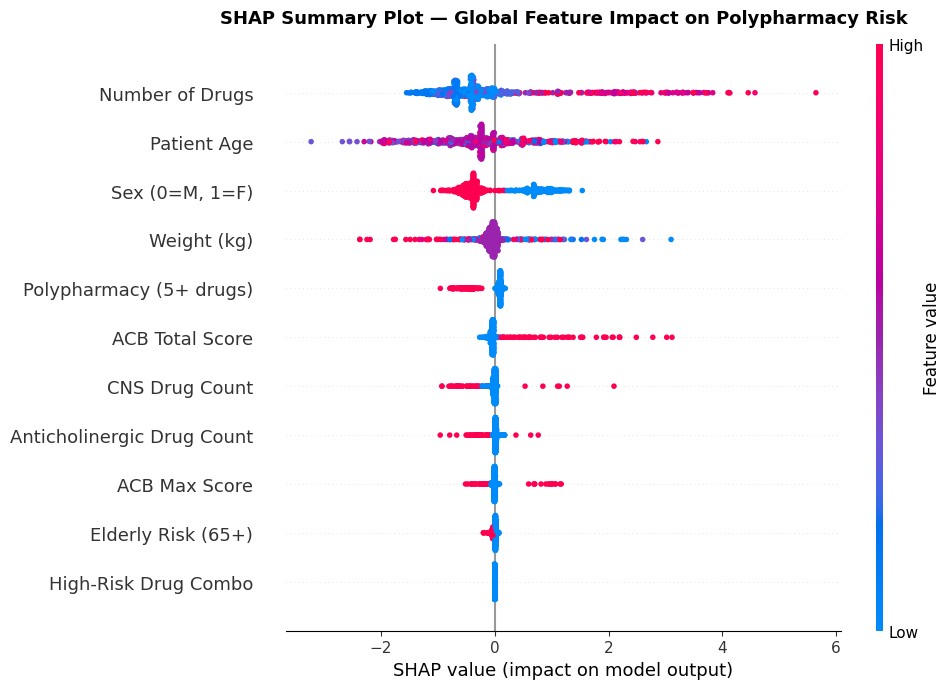

 Saved shap_summary_beeswarm.png


In [16]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_labelled, plot_type='dot', show=False, plot_size=(10,7))
plt.title('SHAP Summary Plot — Global Feature Impact on Polypharmacy Risk',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved shap_summary_beeswarm.png')

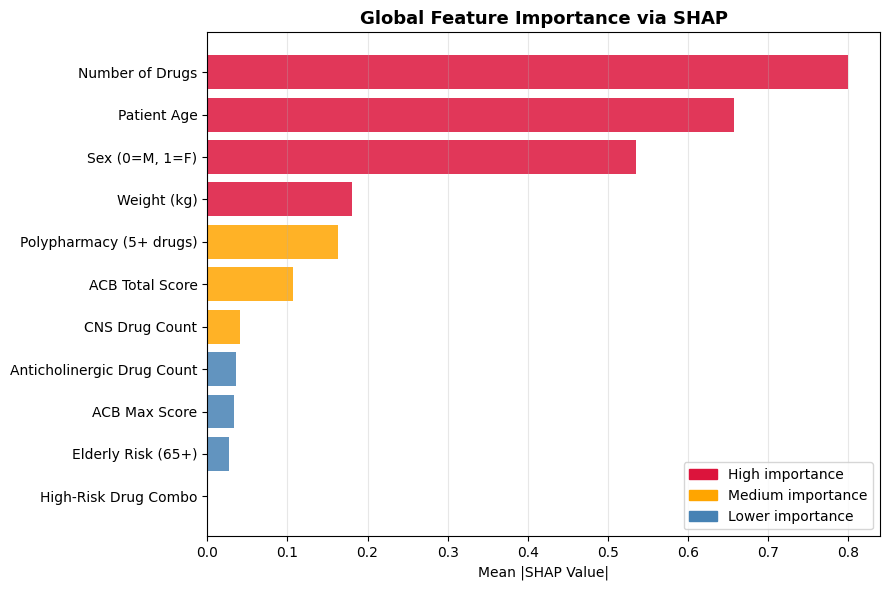

Saved shap_bar_global.png


In [17]:
# Mean absolute SHAP bar chart
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=[FEATURE_LABELS.get(f,f) for f in FEATURE_COLUMNS]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['crimson' if v >= mean_shap.quantile(0.67) else
          'orange'  if v >= mean_shap.quantile(0.33) else 'steelblue' for v in mean_shap.values]
ax.barh(mean_shap.index, mean_shap.values, color=colors, alpha=0.85)
ax.set_xlabel('Mean |SHAP Value|'); ax.grid(axis='x', alpha=0.3)
ax.set_title('Global Feature Importance via SHAP', fontsize=13, fontweight='bold')
high_p = mpatches.Patch(color='crimson',   label='High importance')
mid_p  = mpatches.Patch(color='orange',    label='Medium importance')
low_p  = mpatches.Patch(color='steelblue', label='Lower importance')
ax.legend(handles=[high_p, mid_p, low_p], loc='lower right')
plt.tight_layout()
plt.savefig('shap_bar_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_bar_global.png')

## Local Explainability - Waterfall Plots

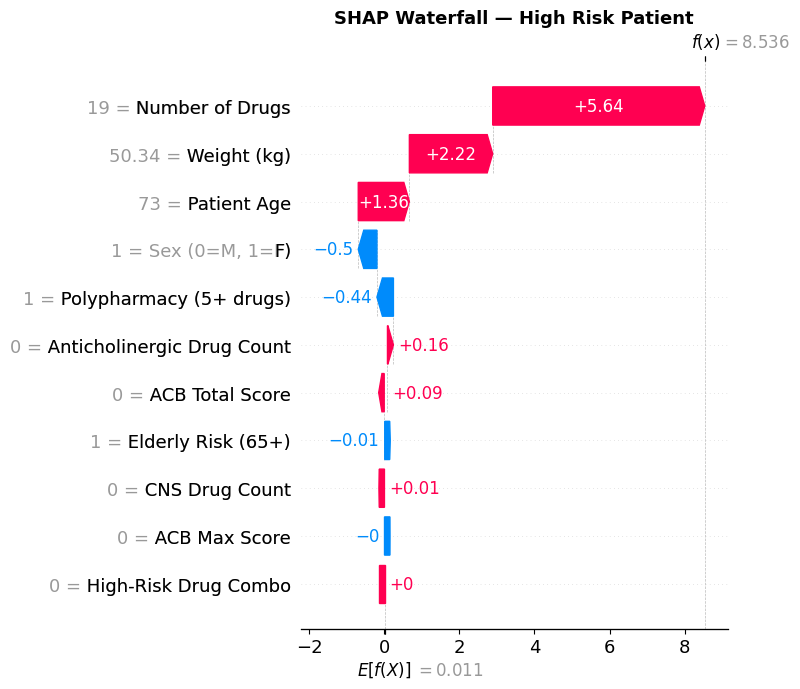

 Saved shap_waterfall_highrisk.png  |  Risk prob: 100.0%  |  Actual: High


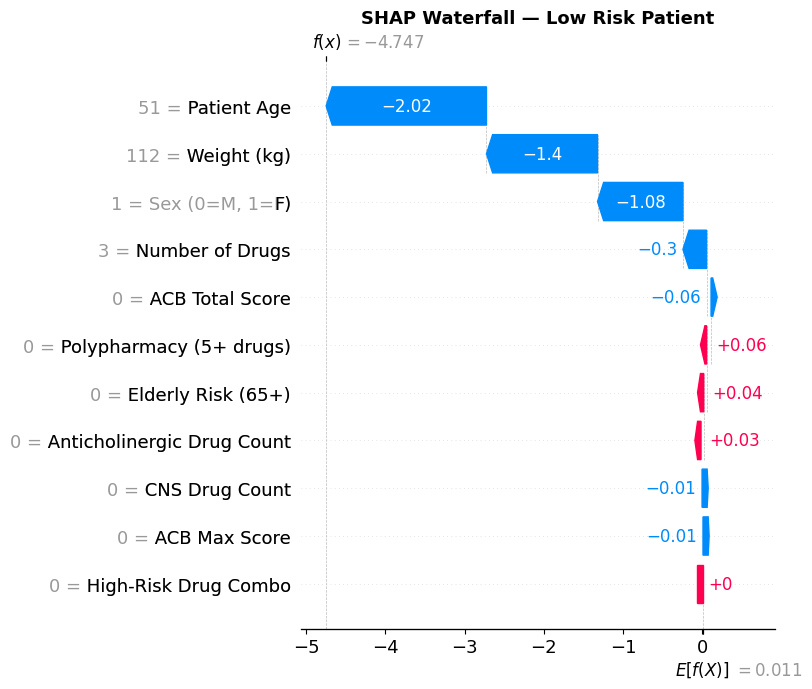

 Saved shap_waterfall_lowrisk.png  |  Risk prob: 0.9%  |  Actual: Low


In [18]:
y_test_arr = np.array(y_test)

# High risk patient, highest predicted probability among true positives
hr_idx = np.where(y_test_arr==1)[0]
patient_idx = hr_idx[np.argmax(y_pred_proba[hr_idx])] if len(hr_idx)>0 else np.argmax(y_pred_proba)

# Low risk patient, lowest predicted probability among true negatives
lr_idx = np.where(y_test_arr==0)[0]
low_patient_idx = lr_idx[np.argmin(y_pred_proba[lr_idx])] if len(lr_idx)>0 else np.argmin(y_pred_proba)

feat_names_labelled = [FEATURE_LABELS.get(f,f) for f in FEATURE_COLUMNS]

for idx, title, fname in [
    (patient_idx,     'High Risk Patient', 'shap_waterfall_highrisk.png'),
    (low_patient_idx, 'Low Risk Patient',  'shap_waterfall_lowrisk.png'),
]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_test.iloc[idx].values,
        feature_names=feat_names_labelled
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, show=False, max_display=11)
    plt.title(f'SHAP Waterfall — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Saved {fname}  |  Risk prob: {y_pred_proba[idx]:.1%}  |  Actual: {"High" if y_test_arr[idx]==1 else "Low"}')

## Age Group Cohort SHAP Analysis

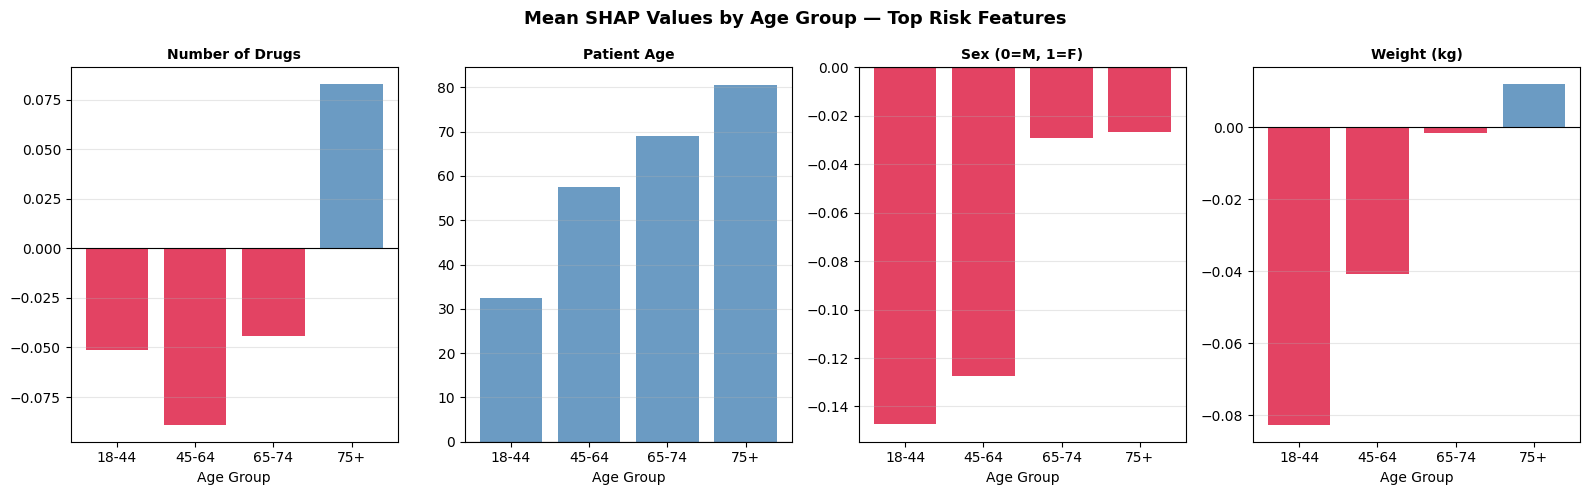

 Saved shap_by_age_group.png


In [19]:
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLUMNS)
shap_df['age'] = X_test['age'].values
shap_df['age_group'] = pd.cut(shap_df['age'], bins=[0,44,64,74,200], labels=['18-44','45-64','65-74','75+'])

top_feats = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLUMNS).nlargest(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, feat in zip(axes, top_feats):
    gm = shap_df.groupby('age_group')[feat].mean()
    ax.bar(gm.index.astype(str), gm.values,
           color=['steelblue' if v>=0 else 'crimson' for v in gm.values], alpha=0.8)
    ax.set_title(FEATURE_LABELS.get(feat,feat), fontsize=10, fontweight='bold')
    ax.set_xlabel('Age Group'); ax.axhline(0, color='black', lw=0.8); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Mean SHAP Values by Age Group — Top Risk Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved shap_by_age_group.png')

## [5.5] Plain-English Explanation Generator

In [20]:
def generate_explanation(patient_features, shap_vals, risk_prob, feature_names):
    risk_pct = risk_prob * 100
    if   risk_pct >= 70: risk_label, risk_msg = 'HIGH RISK',     'This medication profile shows significant polypharmacy risk indicators.'
    elif risk_pct >= 40: risk_label, risk_msg = 'MODERATE RISK', 'This profile shows some risk indicators worth monitoring.'
    else:                risk_label, risk_msg = 'LOW RISK',      'This profile shows relatively low polypharmacy risk indicators.'

    templates = {
        'acb_total':        {'high': lambda v: f'  High anticholinergic burden (ACB={v:.0f}): strongly linked to cognitive decline.',
                             'low':  lambda v: f' Low anticholinergic burden (ACB={v:.0f}).'},
        'acb_max':          {'high': lambda v: f'  Strongly anticholinergic drug present (ACB={v:.0f}/3): high CNS risk.',
                             'low':  lambda v: f' No strongly anticholinergic drug detected (max ACB={v:.0f}).'},
        'num_drugs':        {'high': lambda v: f'  {v:.0f} concurrent medications: increases adverse interaction risk.',
                             'low':  lambda v: f' Relatively few medications ({v:.0f} drugs).'},
        'polypharmacy_flag':{'high': lambda v: f'  Polypharmacy confirmed (5+ drugs): regular medication review recommended.',
                             'low':  lambda v: f' Below polypharmacy threshold.'},
        'high_risk_combo':  {'high': lambda v: f' Dangerous drug combination detected: immediate pharmacist review advised.',
                             'low':  lambda v: f' No known high-risk drug combinations detected.'},
        'cns_drug_count':   {'high': lambda v: f'  {v:.0f} CNS-acting drugs: raises risk of sedation, falls, cognitive impairment.',
                             'low':  lambda v: f' Few CNS-acting medications ({v:.0f}).'},
        'age_risk':         {'high': lambda v: f'  Patient aged 65+: heightened drug sensitivity due to reduced clearance.',
                             'low':  lambda v: f' Below elevated-vulnerability age threshold.'},
    }

    sorted_feats = sorted(zip(feature_names, shap_vals,
                              [patient_features.get(f,0) for f in feature_names]),
                          key=lambda x: abs(x[1]), reverse=True)
    lines = [
        'POLYGUARD RISK ASSESSMENT', '='*45,
        f'Overall Risk:     {risk_label}',
        f'Risk Probability: {risk_pct:.1f}%', '',
        risk_msg, '', 'KEY RISK FACTORS:', '-'*45
    ]
    shown = 0
    for feat, sv, fv in sorted_feats:
        if shown >= 5 or abs(sv) < 0.01: continue
        if feat in templates:
            lines.append(templates[feat]['high' if sv>0 else 'low'](fv))
            shown += 1
    lines += ['', 'DISCLAIMER:', '-'*45,
              'For informational purposes only. Not medical advice.',
              'Always consult your doctor or pharmacist.']
    return '\n'.join(lines)

print(' Explanation generator defined\n')

# Test on high-risk and low-risk patient
for idx, label in [(patient_idx, 'HIGH RISK'), (low_patient_idx, 'LOW RISK')]:
    print('='*50)
    print(f'EXAMPLE — {label} PATIENT')
    print('='*50)
    print(generate_explanation(
        dict(zip(FEATURE_COLUMNS, X_test.iloc[idx].values)),
        shap_values[idx], y_pred_proba[idx], FEATURE_COLUMNS
    ))
    print()

 Explanation generator defined

EXAMPLE — HIGH RISK PATIENT
POLYGUARD RISK ASSESSMENT
Overall Risk:     HIGH RISK
Risk Probability: 100.0%

This medication profile shows significant polypharmacy risk indicators.

KEY RISK FACTORS:
---------------------------------------------
  19 concurrent medications: increases adverse interaction risk.
 Below polypharmacy threshold.
  High anticholinergic burden (ACB=0): strongly linked to cognitive decline.
 Below elevated-vulnerability age threshold.

DISCLAIMER:
---------------------------------------------
For informational purposes only. Not medical advice.
Always consult your doctor or pharmacist.

EXAMPLE — LOW RISK PATIENT
POLYGUARD RISK ASSESSMENT
Overall Risk:     LOW RISK
Risk Probability: 0.9%

This profile shows relatively low polypharmacy risk indicators.

KEY RISK FACTORS:
---------------------------------------------
 Relatively few medications (3 drugs).
 Low anticholinergic burden (ACB=0).
  Polypharmacy confirmed (5+ drugs): regu

## Save SHAP Artefacts for Webapp

In [21]:
import dill

with open('polyguard_explainer.pkl','wb') as f:
    dill.dump({'explainer': explainer, 'feature_labels': FEATURE_LABELS, 'explain_fn': generate_explanation}, f)

pd.DataFrame({
    'feature':   FEATURE_COLUMNS,
    'label':     [FEATURE_LABELS.get(f,f) for f in FEATURE_COLUMNS],
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).to_csv('shap_feature_importance.csv', index=False)

print(' STEP 5 COMPLETE — SHAP artefacts saved')
print('   polyguard_explainer.pkl | shap_feature_importance.csv')

 STEP 5 COMPLETE — SHAP artefacts saved
   polyguard_explainer.pkl | shap_feature_importance.csv


---
## Full Pipeline Complete

All output files are saved and ready for the development of a webapp

| File | Used in |
|---|---|
| `polyguard_dataset.csv` | Reference / dissertation |
| `polyguard_features.csv` | Model input |
| `polyguard_model.pkl` | Webapp predictions |
| `polyguard_scaler.pkl` | Webapp preprocessing |
| `polyguard_explainer.pkl` | Webapp SHAP explanations |
| `polyguard_features_list.json` | Webapp feature ordering |
| `shap_feature_importance.csv` | Webapp importance chart |
| `*.png` (7 figures) | Dissertation figures |

In [22]:
print('='*60)
print('         POLYGUARD PIPELINE COMPLETE SUMMARY')
print('='*60)
print(f'  Dataset records:   {len(df)}')
print(f'  Features:          {len(FEATURE_COLUMNS)}')
print(f'  High risk cases:   {df["risk_label"].sum()} ({df["risk_label"].mean()*100:.1f}%)')
print(f'  Model:             XGBoost (tuned, SMOTE-balanced)')
print(f'  ROC-AUC (test):    {roc_auc_score(y_test, y_proba):.4f}')
print(f'  F1 Score (test):   {f1_score(y_test, y_pred):.4f}')
print(f'  CV ROC-AUC:        {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Explainability:    SHAP TreeExplainer ({shap_values.shape[0]} patients)')
print('='*60)


         POLYGUARD PIPELINE COMPLETE SUMMARY
  Dataset records:   4792
  Features:          11
  High risk cases:   1399 (29.2%)
  Model:             XGBoost (tuned, SMOTE-balanced)
  ROC-AUC (test):    0.6535
  F1 Score (test):   0.4796
  CV ROC-AUC:        0.7960 ± 0.0138
  Explainability:    SHAP TreeExplainer (959 patients)
